# Importamos las bibliotecas y cargamos los datos

In [222]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import math

In [223]:
df = pd.read_csv('HW01_data_eveh.csv', delimiter=";", decimal=',')

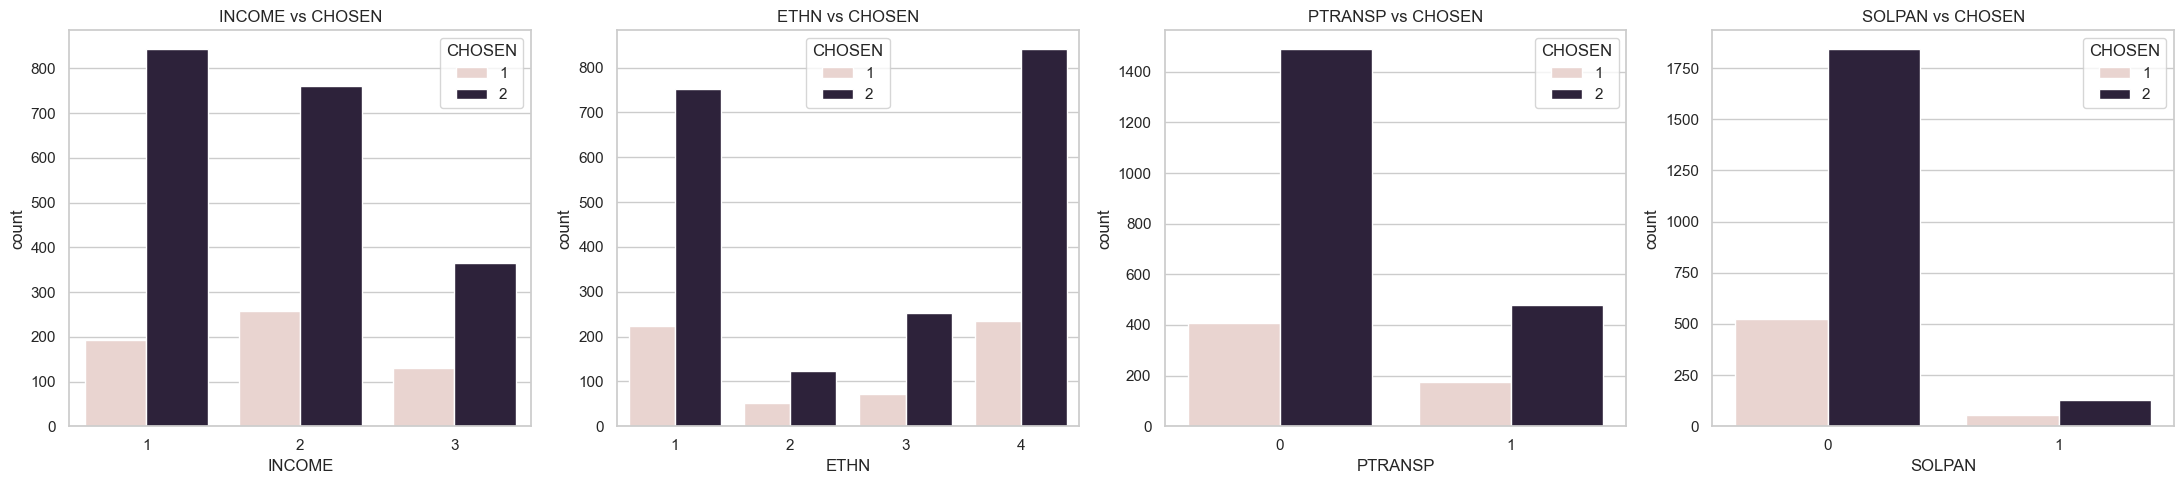

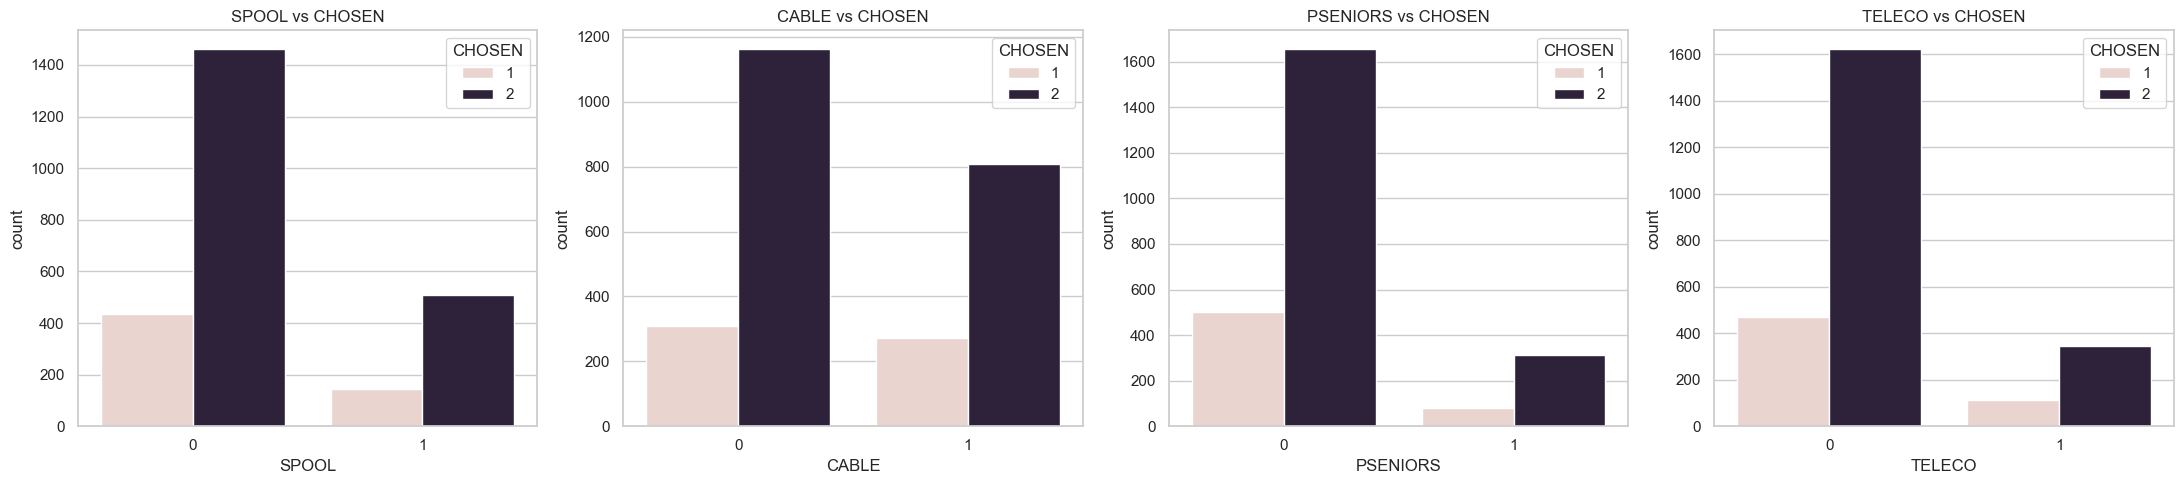

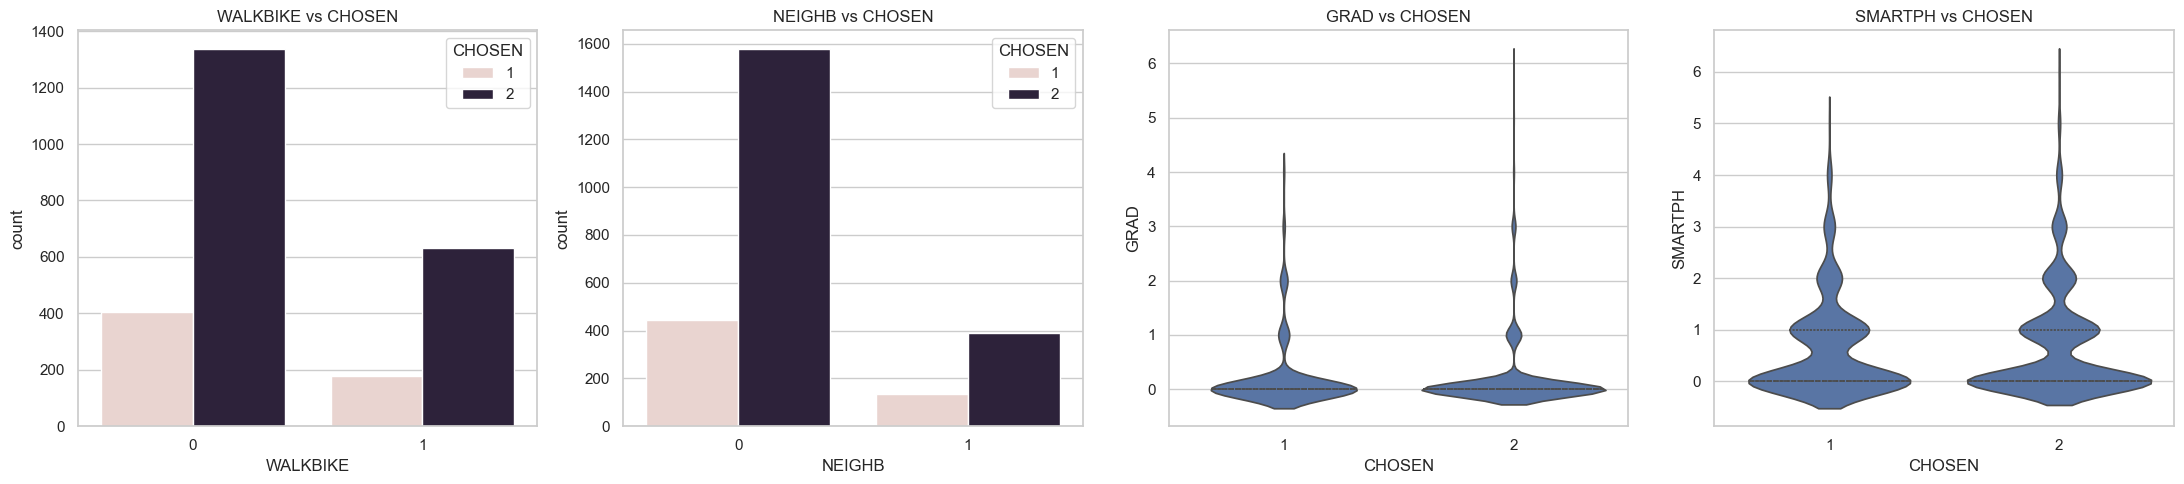

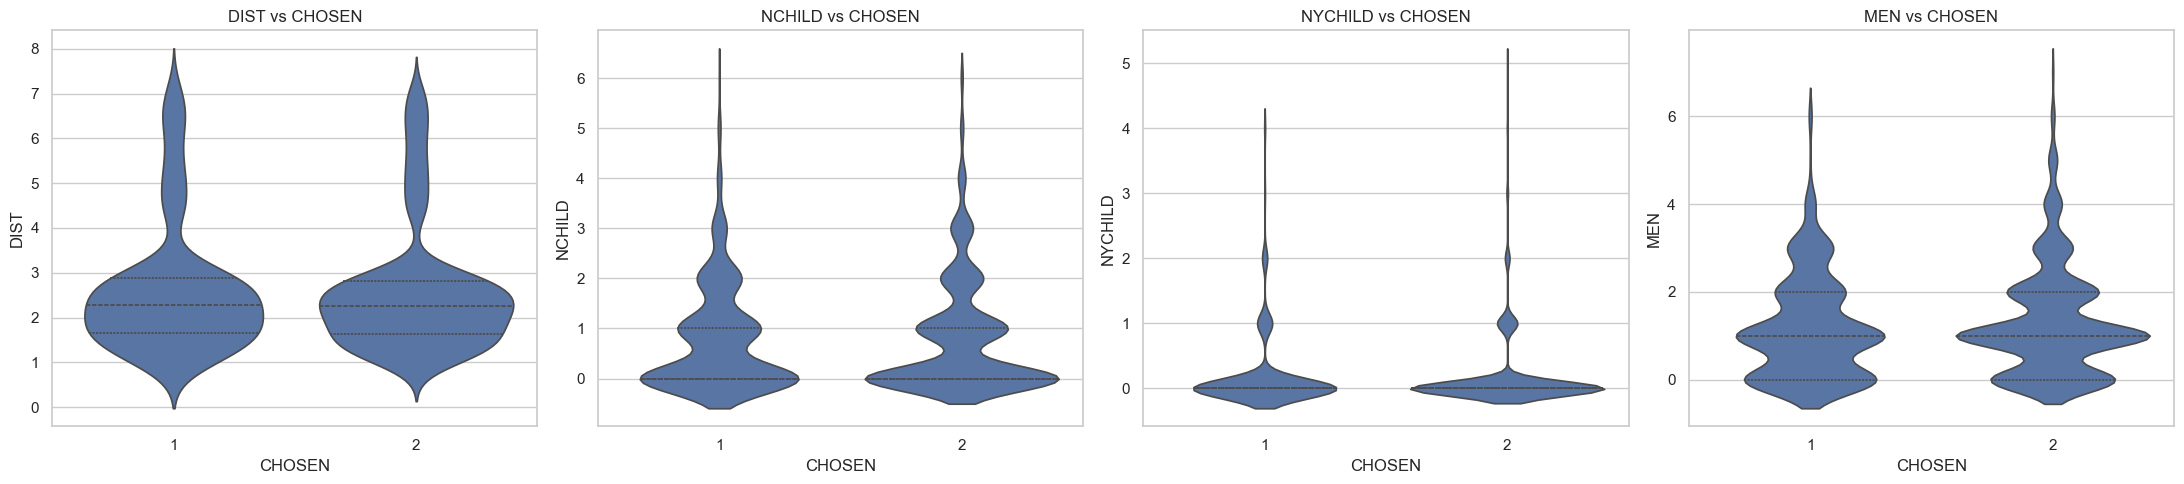

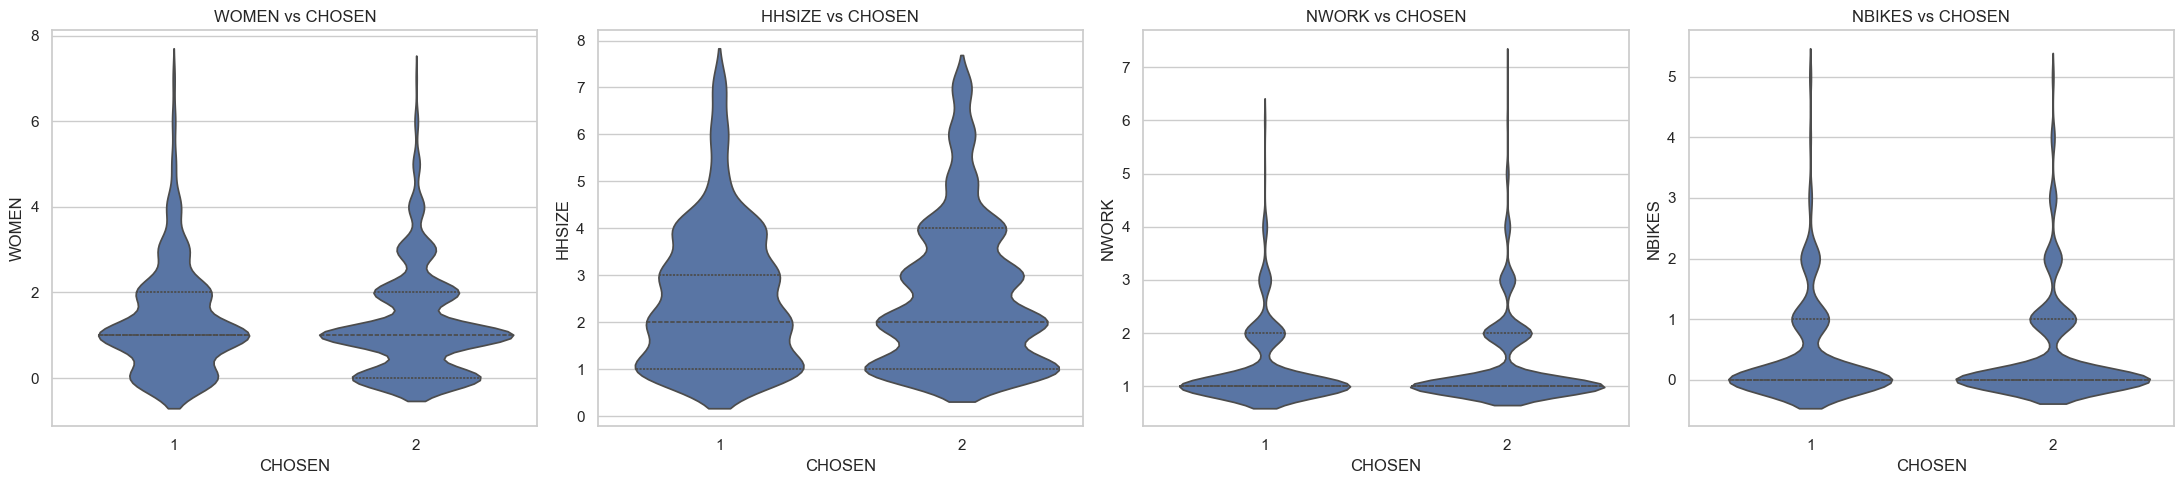

In [224]:
# Configuración de variables y tipo de gráfico (sin COST)
config = {
    'INCOME': 'count',
    'ETHN': 'count',
    'PTRANSP': 'count',
    'SOLPAN': 'count',
    'SPOOL': 'count',
    'CABLE': 'count',
    'PSENIORS': 'count',
    'TELECO': 'count',
    'WALKBIKE': 'count',
    'NEIGHB': 'count',
    'UNO': 'omit',
    'CHOSEN': 'omit',
    'HHID': 'omit',
    'GRAD': 'violin',
    'SMARTPH': 'violin',
    'DIST': 'violin',
    'NCHILD': 'violin',
    'NYCHILD': 'violin',
    'MEN': 'violin',
    'WOMEN': 'violin',
    'HHSIZE': 'violin',
    'NWORK': 'violin',
    'NBIKES': 'violin'
}

# Lista de variables válidas
valid_vars = [var for var, kind in config.items() if kind != 'omit']
plots = [(var, config[var]) for var in valid_vars]

# Mostrar gráficos en bloques de 4 por fila
for i in range(0, len(plots), 4):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for j, (var, kind) in enumerate(plots[i:i+4]):
        ax = axes[j]
        title = f'{var} vs CHOSEN'
        if kind == 'count':
            sns.countplot(data=df, x=var, hue='CHOSEN', ax=ax)
        elif kind == 'violin':
            sns.violinplot(data=df, x='CHOSEN', y=var, inner='quartile', ax=ax)
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [225]:
print(df['CHOSEN'].value_counts(normalize=True) * 100)

CHOSEN
2    77.215686
1    22.784314
Name: proportion, dtype: float64


In [226]:
print(df.groupby('CHOSEN')[['GRAD','DIST','SMARTPH','NCHILD','NYCHILD','HHSIZE','MEN','WOMEN','NWORK','NBIKES']].agg(['mean', 'std']).round(2))

        GRAD        DIST       SMARTPH       NCHILD       NYCHILD        \
        mean   std  mean   std    mean   std   mean   std    mean   std   
CHOSEN                                                                    
1       0.21  0.63  2.62  1.47    0.65  0.93   0.81  1.06    0.18  0.54   
2       0.20  0.64  2.59  1.45    0.71  1.04   0.83  1.14    0.17  0.52   

       HHSIZE         MEN       WOMEN       NWORK       NBIKES        
         mean   std  mean   std  mean   std  mean   std   mean   std  
CHOSEN                                                                
1        2.56  1.49  1.19  1.16  1.37  1.26  1.36  0.74   0.43  0.84  
2        2.61  1.57  1.33  1.25  1.28  1.22  1.41  0.80   0.46  0.89  


In [227]:
binarias = ['PTRANSP', 'PSENIORS', 'SOLPAN', 'SPOOL', 'WALKBIKE', 'TELECO', 'NEIGHB', 'CABLE']
for i in binarias:
    print(f"\n{i} vs CHOSEN:")
    print(pd.crosstab(df[i], df['CHOSEN'], normalize='index').round(3) * 100)


PTRANSP vs CHOSEN:
CHOSEN      1     2
PTRANSP            
0        21.4  78.6
1        26.7  73.3

PSENIORS vs CHOSEN:
CHOSEN       1     2
PSENIORS            
0         23.2  76.8
1         20.3  79.7

SOLPAN vs CHOSEN:
CHOSEN     1     2
SOLPAN            
0       22.2  77.8
1       30.2  69.8

SPOOL vs CHOSEN:
CHOSEN     1     2
SPOOL             
0       23.0  77.0
1       22.2  77.8

WALKBIKE vs CHOSEN:
CHOSEN       1     2
WALKBIKE            
0         23.2  76.8
1         21.9  78.1

TELECO vs CHOSEN:
CHOSEN     1     2
TELECO            
0       22.5  77.5
1       24.2  75.8

NEIGHB vs CHOSEN:
CHOSEN     1     2
NEIGHB            
0       22.0  78.0
1       25.6  74.4

CABLE vs CHOSEN:
CHOSEN     1     2
CABLE             
0       21.1  78.9
1       25.1  74.9


In [228]:
print(df[numericas].describe().T[['mean','std','min','max']])

             mean       std       min       max
GRAD     0.205098  0.633736  0.000000  6.000000
DIST     2.600935  1.455136  0.770238  7.187515
SMARTPH  0.694902  1.018201  0.000000  6.000000
NCHILD   0.824314  1.125560  0.000000  6.000000
NYCHILD  0.172157  0.523824  0.000000  5.000000
HHSIZE   2.601176  1.555486  1.000000  7.000000
MEN      1.300392  1.228008  0.000000  7.000000
WOMEN    1.300784  1.229987  0.000000  7.000000
NWORK    1.397647  0.788995  1.000000  7.000000
NBIKES   0.450588  0.877618  0.000000  5.000000


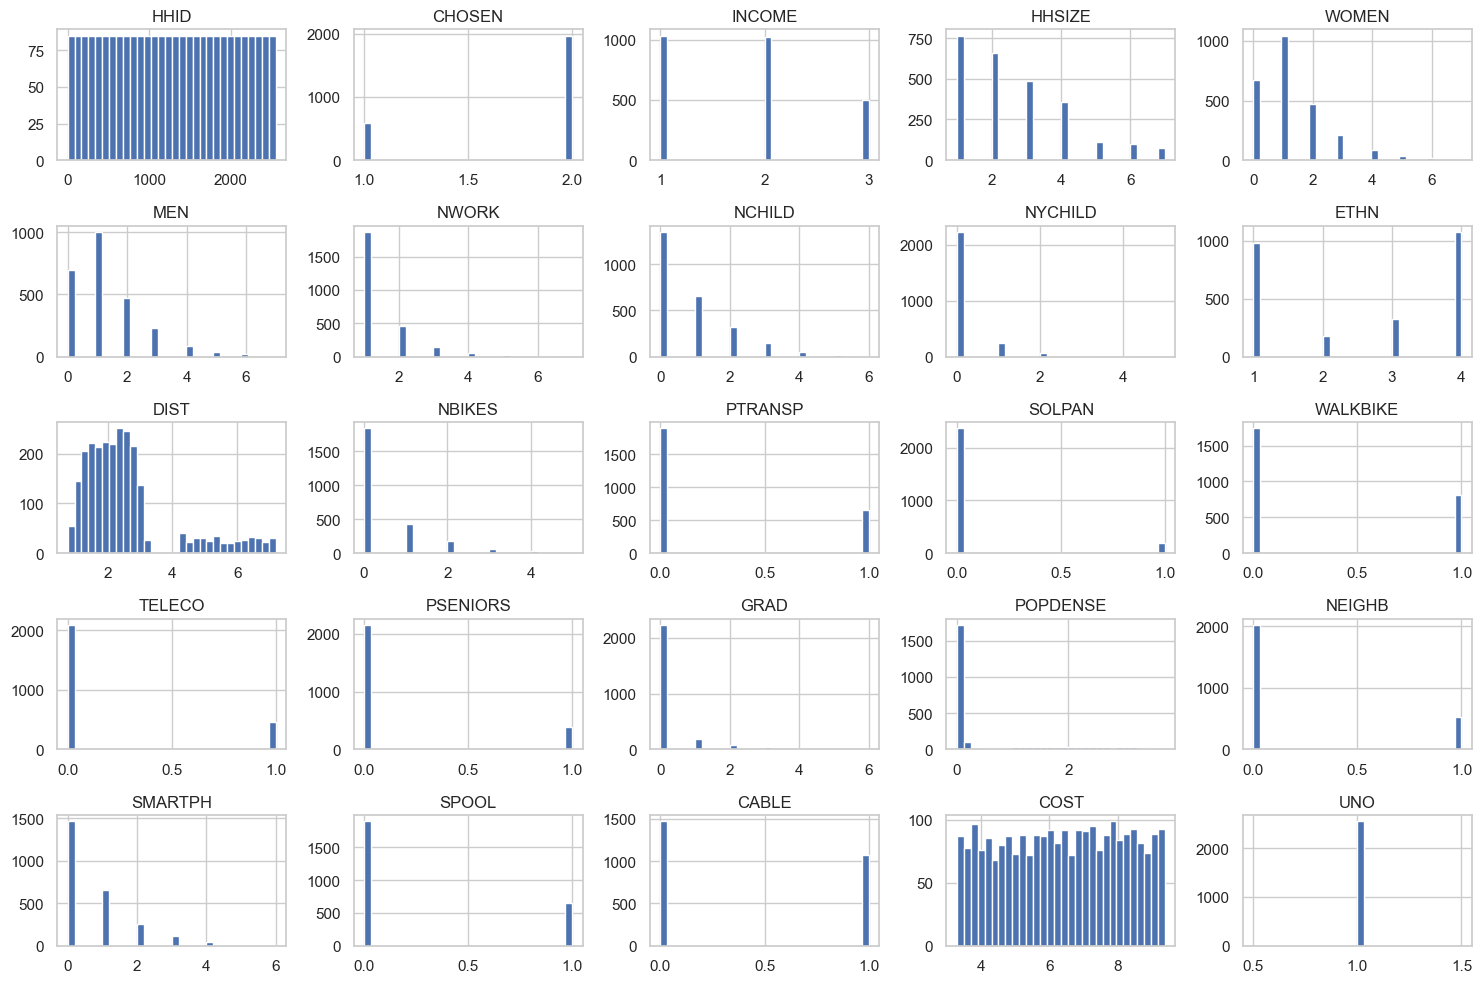

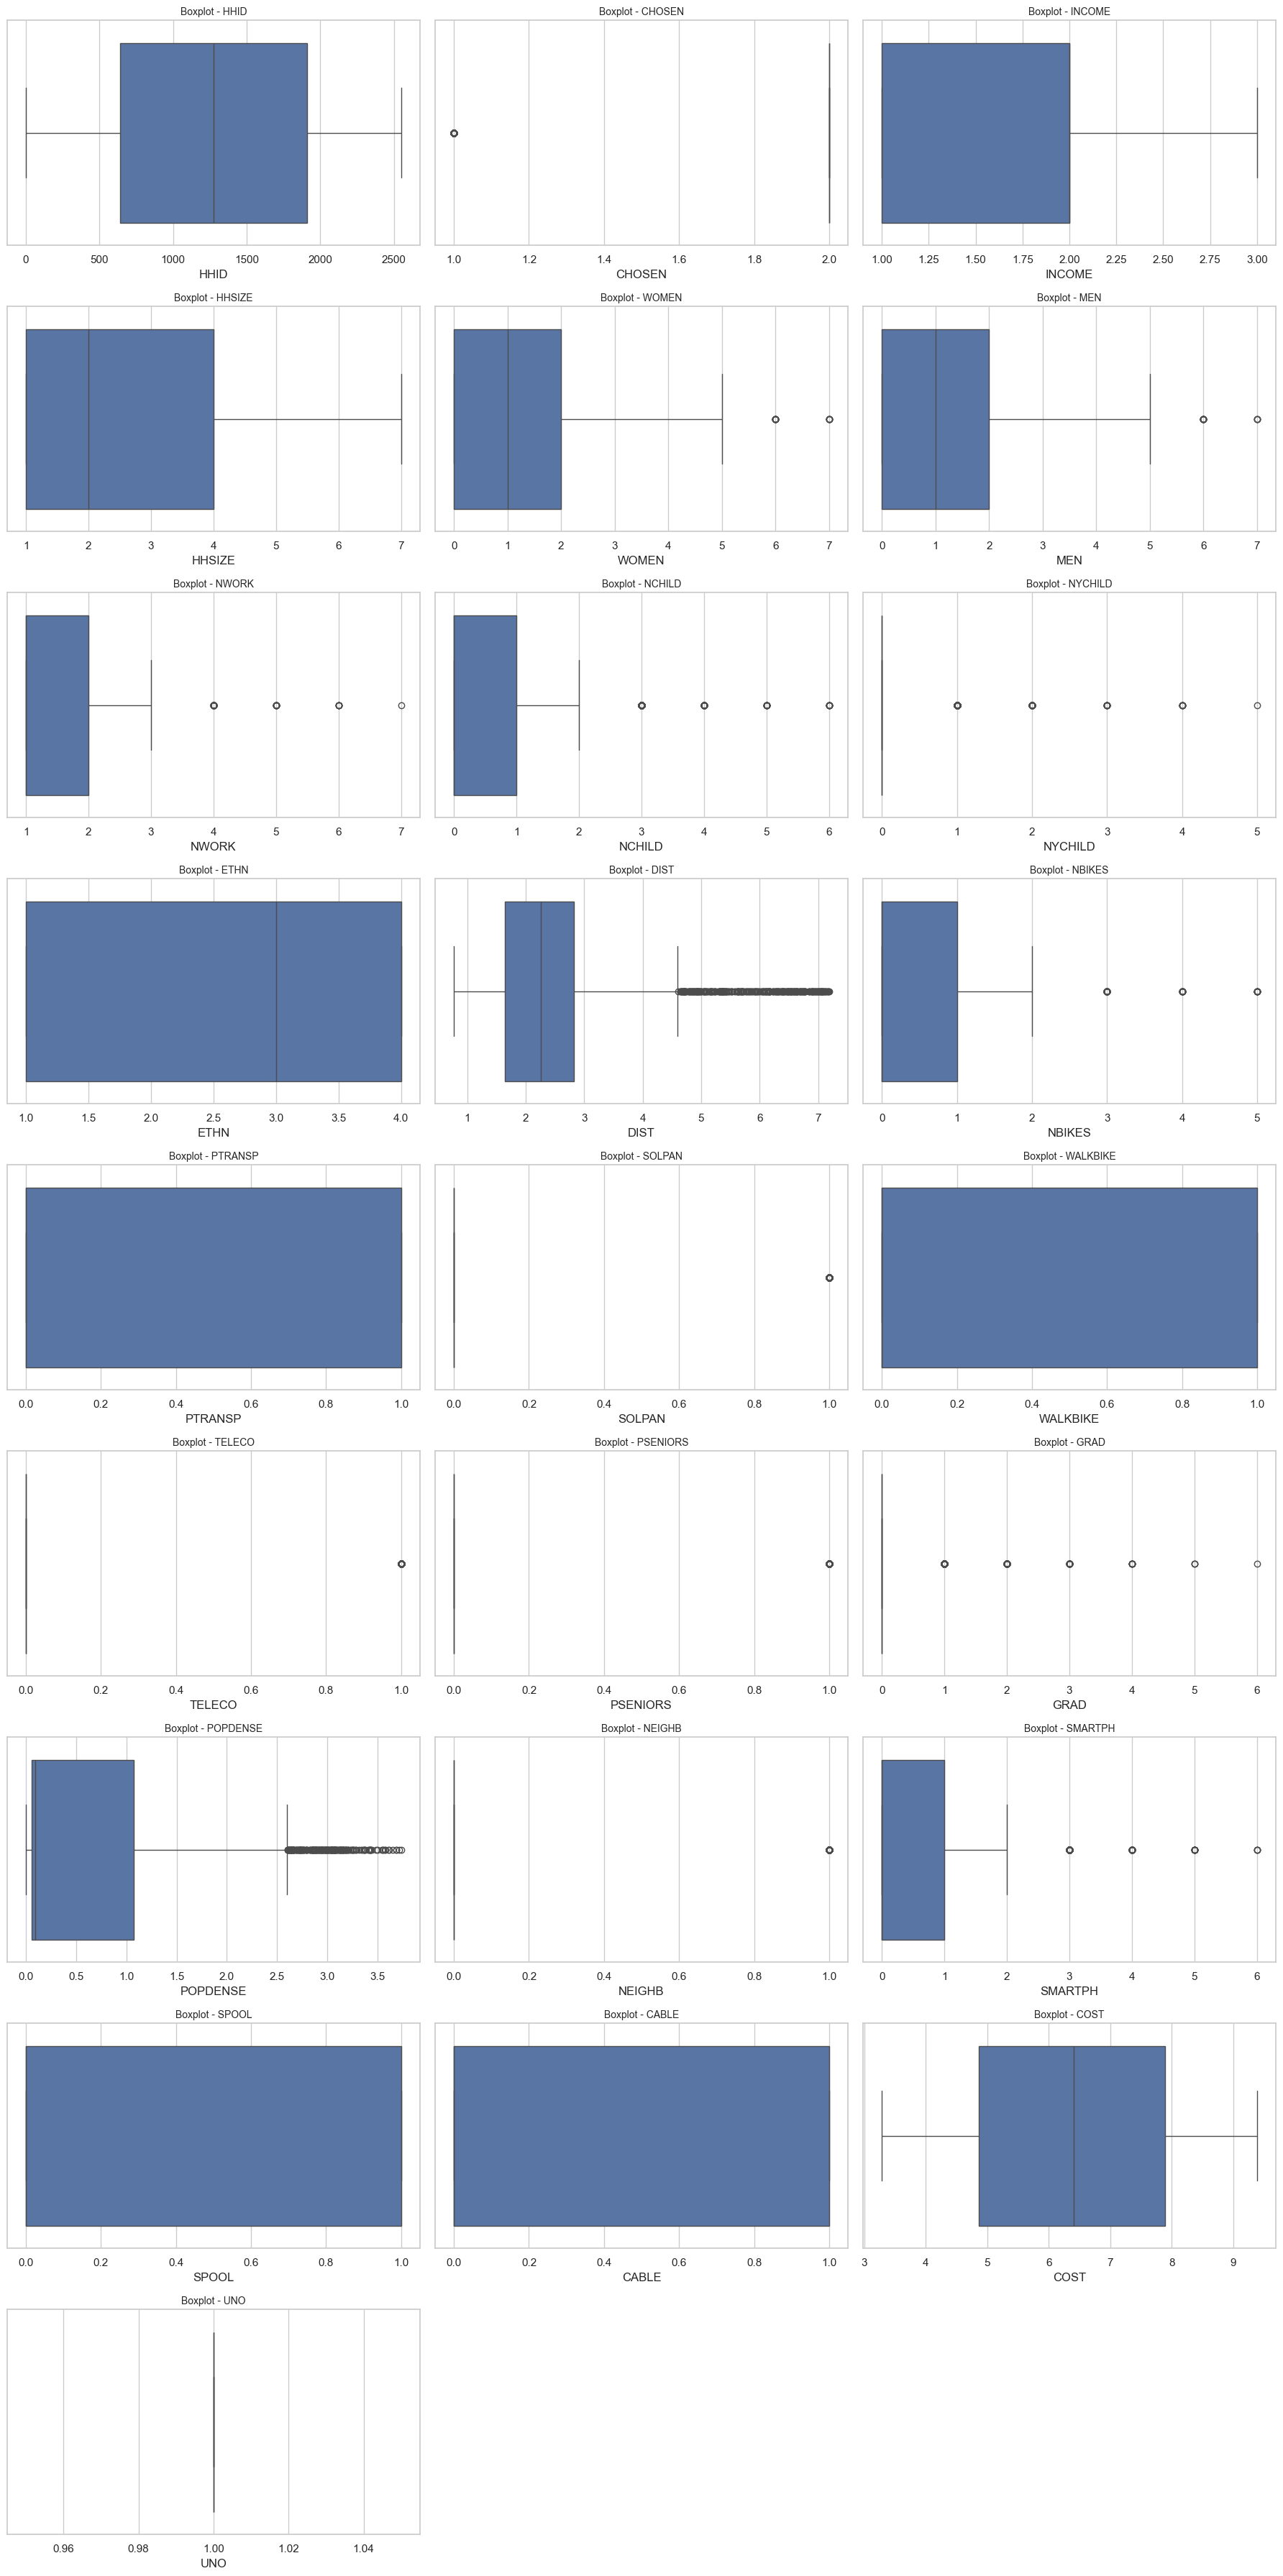

In [229]:
# 1. Histogramas para ver distribuciones (excluyendo columnas binarias)
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# 2. Boxplots organizados de 3 en 3 por fila
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Configurar diseño de los subplots
cols_per_row = 3
total = len(numeric_cols)
rows = math.ceil(total / cols_per_row)

# Crear figura con subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(6 * cols_per_row, 4 * rows))
axes = axes.flatten()  # Aplanar para fácil acceso

# Dibujar cada boxplot
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot - {col}', fontsize=10)

# Ocultar subplots vacíos (si los hay)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [230]:
df.head()

,HHID,CHOSEN,INCOME,HHSIZE,WOMEN,MEN,NWORK,NCHILD,NYCHILD,ETHN,...,TELECO,PSENIORS,GRAD,POPDENSE,NEIGHB,SMARTPH,SPOOL,CABLE,COST,UNO
0,1,2,3,4,1,3,1,0,0,1,...,0,1,2,0.123468,0,3,1,1,5.407897,1
1,2,2,1,6,3,3,6,0,0,4,...,0,0,0,0.031422,1,3,0,1,8.278960,1
2,3,1,3,2,0,2,1,0,0,4,...,0,1,1,0.131637,1,0,0,1,3.858729,1
3,4,1,2,2,1,1,1,1,0,2,...,0,0,0,0.071255,0,0,0,0,5.782505,1
4,5,2,1,6,2,4,5,1,0,4,...,0,0,0,0.036714,0,2,0,0,6.614290,1


Cambiamos los nombres a las columnas de datos

In [231]:
q33_pop = df['POPDENSE'].quantile(0.33)
q66_pop = df['POPDENSE'].quantile(0.66)

df['POPD_BAJO']  = (df['POPDENSE'] <= q33_pop).astype(int)
df['POPD_MEDIA'] = ((df['POPDENSE'] > q33_pop) & (df['POPDENSE'] <= q66_pop)).astype(int)
df['POPD_ALTO']  = (df['POPDENSE'] > q66_pop).astype(int)


q33_dist = df['DIST'].quantile(0.33)
q66_dist = df['DIST'].quantile(0.66)

df['DIST_CORTA']  = (df['DIST'] <= q33_dist).astype(int)
df['DIST_MEDIA']  = ((df['DIST'] > q33_dist) & (df['DIST'] <= q66_dist)).astype(int)
df['DIST_LARGA']  = (df['DIST'] > q66_dist).astype(int)

df['HOGAR_PEQUEÑO'] = (df['HHSIZE'] <= 2).astype(int)
df['HOGAR_MEDIANO'] = ((df['HHSIZE'] > 2) & (df['HHSIZE'] <= 4)).astype(int)
df['HOGAR_GRANDE']  = (df['HHSIZE'] > 4).astype(int)

# Calcular percentiles 33% y 66% para COST
q33_cost = df['COST'].quantile(0.33)
q66_cost = df['COST'].quantile(0.66)

# Crear variables binarias para COST
df['COST_BAJO']   = (df['COST'] <= q33_cost).astype(int)
df['COST_MEDIO']  = ((df['COST'] > q33_cost) & (df['COST'] <= q66_cost)).astype(int)
df['COST_ALTO']   = (df['COST'] > q66_cost).astype(int)

In [232]:
df['PTRANSP_CORTA']  = df['PTRANSP'] * df['DIST_CORTA']
df['PTRANSP_MEDIA']  = df['PTRANSP'] * df['DIST_MEDIA']
df['PTRANSP_LARGA']  = df['PTRANSP'] * df['DIST_LARGA']

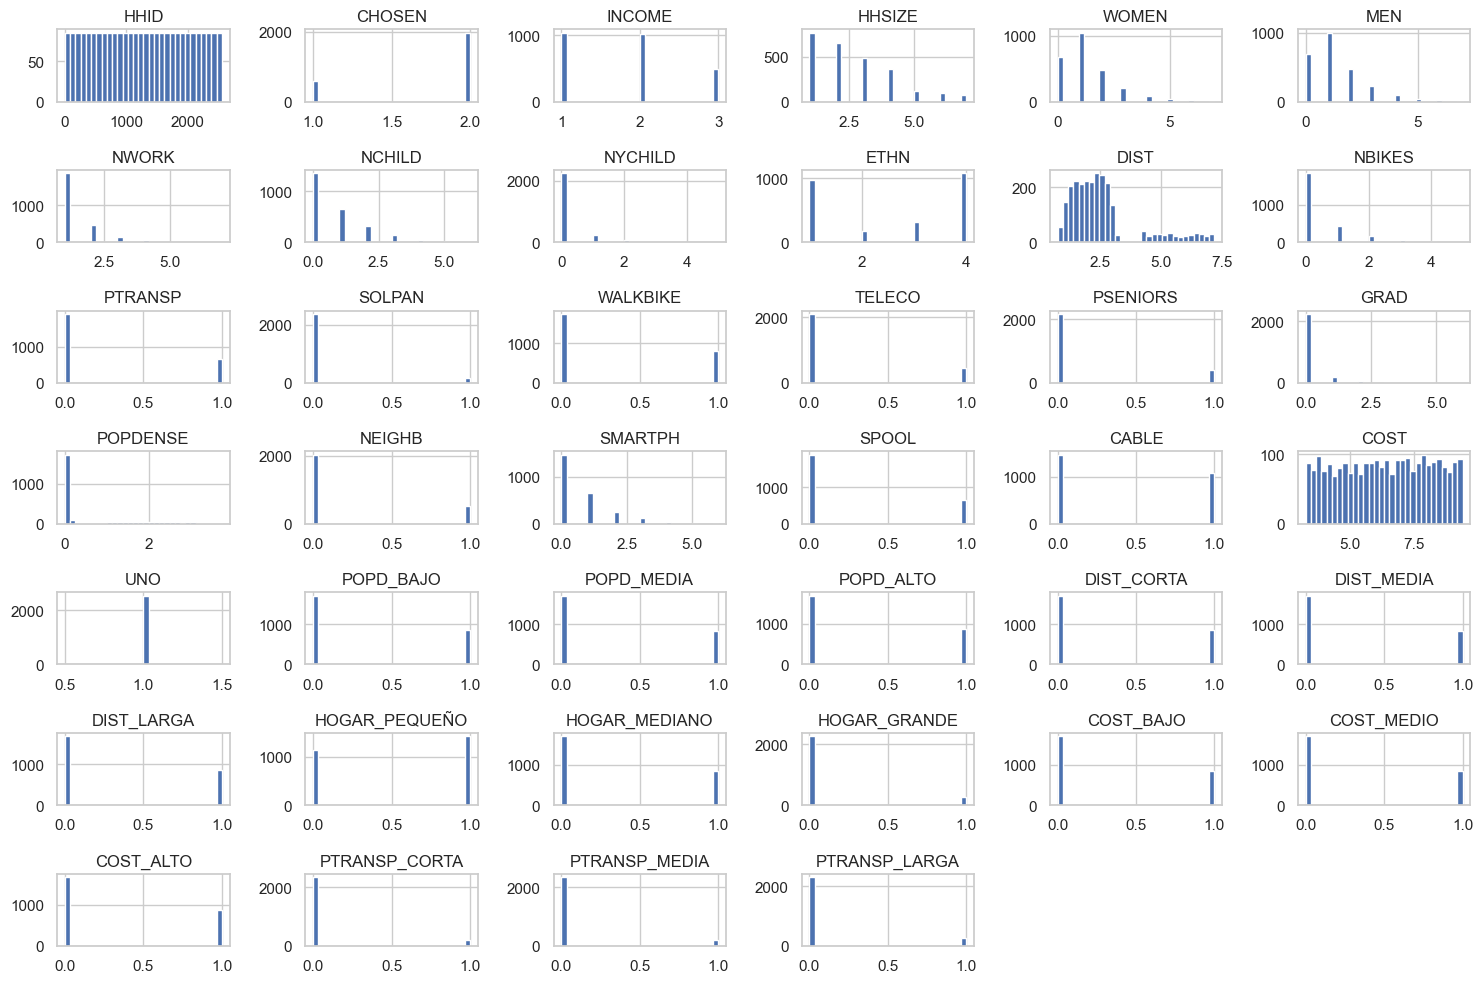

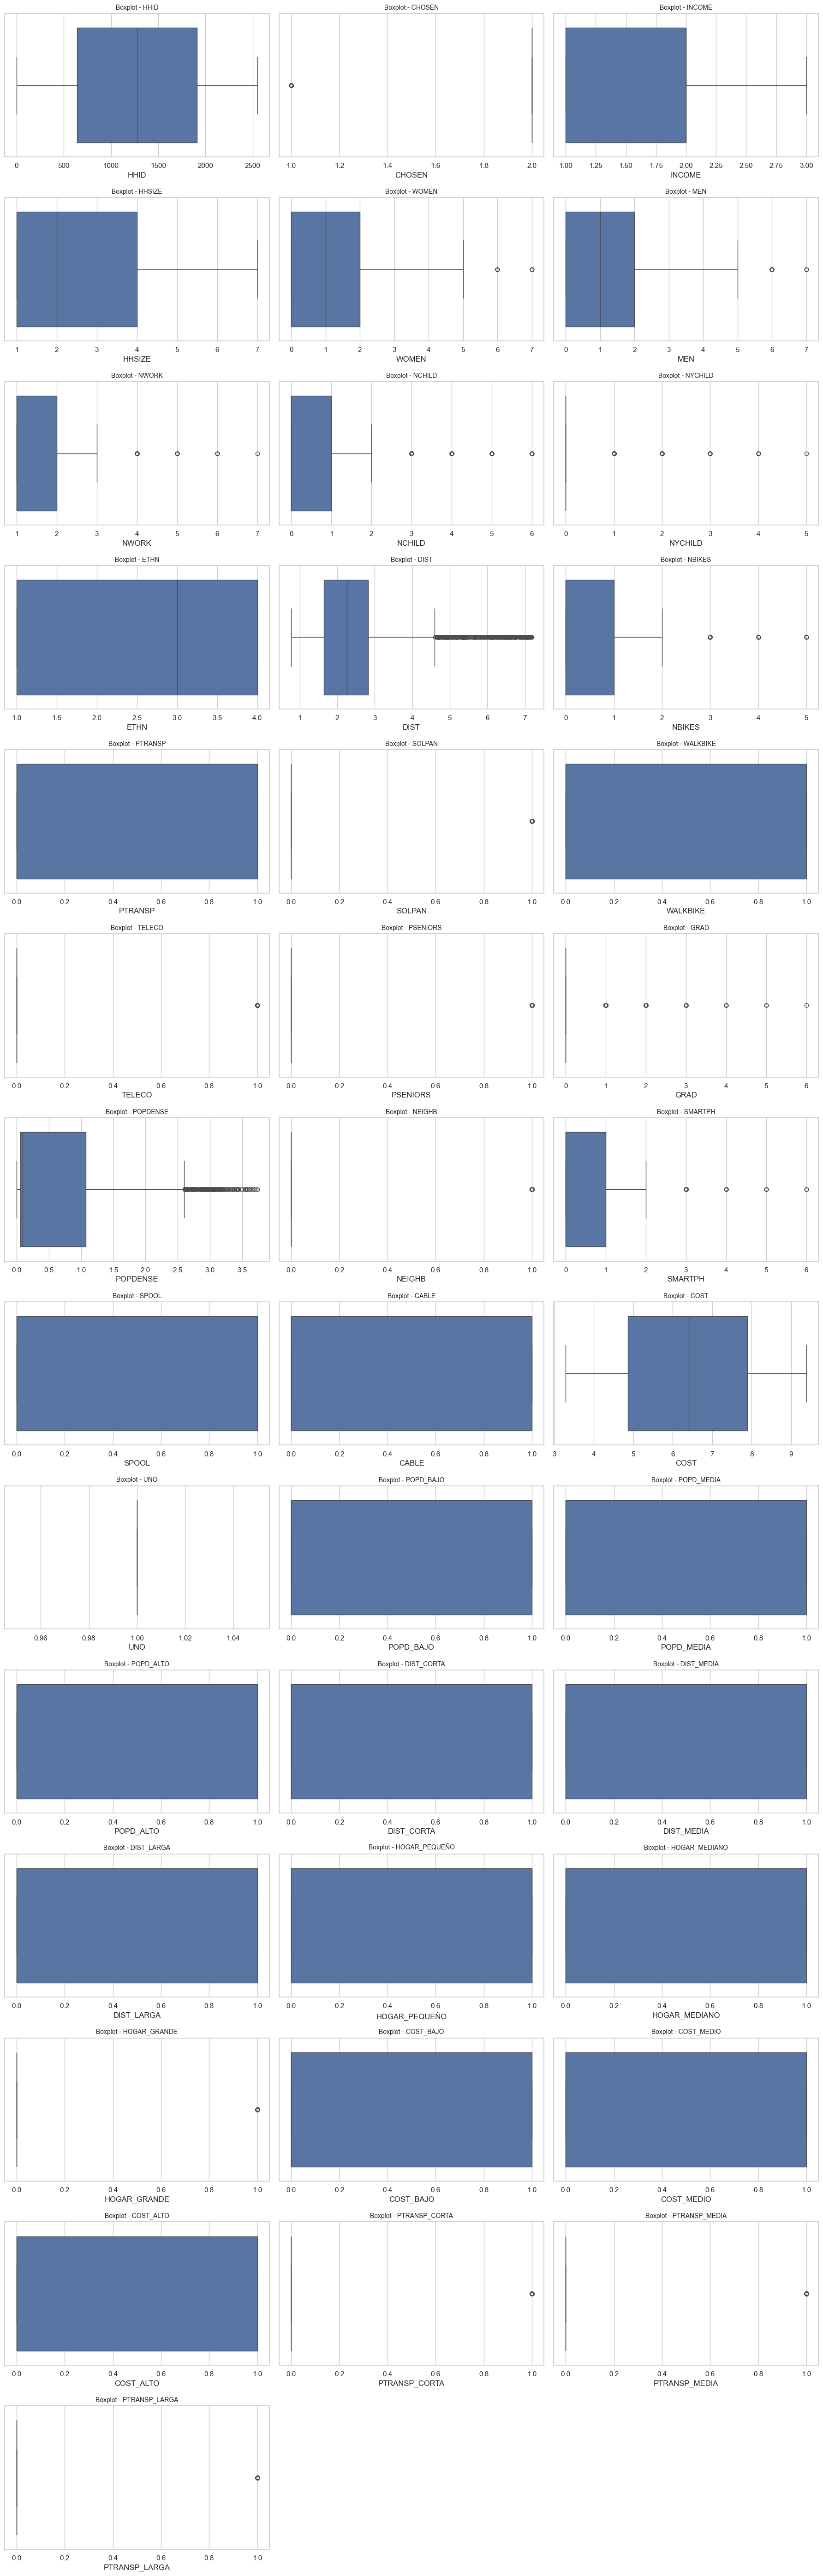

In [233]:
# Excluir columnas binarias del DataFrame
df_non_binary = df

# 1. Histogramas para ver distribuciones (excluyendo columnas binarias)
df_non_binary.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# 2. Boxplots organizados de 3 en 3 por fila
numeric_cols = df_non_binary.select_dtypes(include=[np.number]).columns

# Configurar diseño de los subplots
cols_per_row = 3
total = len(numeric_cols)
rows = math.ceil(total / cols_per_row)

# Crear figura con subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(6 * cols_per_row, 4 * rows))
axes = axes.flatten()  # Aplanar para fácil acceso

# Dibujar cada boxplot
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_non_binary[col], ax=axes[i])
    axes[i].set_title(f'Boxplot - {col}', fontsize=10)

# Ocultar subplots vacíos (si los hay)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Limpieza de datos

In [234]:
df

,HHID,CHOSEN,INCOME,HHSIZE,WOMEN,MEN,NWORK,NCHILD,NYCHILD,ETHN,...,DIST_LARGA,HOGAR_PEQUEÑO,HOGAR_MEDIANO,HOGAR_GRANDE,COST_BAJO,COST_MEDIO,COST_ALTO,PTRANSP_CORTA,PTRANSP_MEDIA,PTRANSP_LARGA
0,1,2,3,4,1,3,1,0,0,1,...,0,0,1,0,0,1,0,0,0,0
1,2,2,1,6,3,3,6,0,0,4,...,0,0,0,1,0,0,1,0,0,0
2,3,1,3,2,0,2,1,0,0,4,...,1,1,0,0,1,0,0,0,0,0
3,4,1,2,2,1,1,1,1,0,2,...,0,1,0,0,0,1,0,0,0,0
4,5,2,1,6,2,4,5,1,0,4,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2545,2546,2,1,3,2,1,1,2,1,2,...,0,0,1,0,1,0,0,0,0,0
2546,2547,2,3,1,1,0,1,0,0,1,...,0,1,0,0,0,1,0,0,1,0
2547,2548,2,1,1,0,1,1,0,0,2,...,1,1,0,0,1,0,0,0,0,0
2548,2549,2,2,4,1,3,1,1,0,2,...,0,0,1,0,1,0,0,0,0,0


In [235]:
df.dtypes

HHID               int64
CHOSEN             int64
INCOME             int64
HHSIZE             int64
WOMEN              int64
MEN                int64
NWORK              int64
NCHILD             int64
NYCHILD            int64
ETHN               int64
DIST             float64
NBIKES             int64
PTRANSP            int64
SOLPAN             int64
WALKBIKE           int64
TELECO             int64
PSENIORS           int64
GRAD               int64
POPDENSE         float64
NEIGHB             int64
SMARTPH            int64
SPOOL              int64
CABLE              int64
COST             float64
UNO                int64
POPD_BAJO          int32
POPD_MEDIA         int32
POPD_ALTO          int32
DIST_CORTA         int32
DIST_MEDIA         int32
DIST_LARGA         int32
HOGAR_PEQUEÑO      int32
HOGAR_MEDIANO      int32
HOGAR_GRANDE       int32
COST_BAJO          int32
COST_MEDIO         int32
COST_ALTO          int32
PTRANSP_CORTA      int64
PTRANSP_MEDIA      int64
PTRANSP_LARGA      int64


In [236]:
df["CHOSEN"] = df["CHOSEN"].replace(1, 0)


In [237]:
df["CHOSEN"] = df["CHOSEN"].replace(2, 1)

In [238]:
df.to_csv("archivo_final.csv", index=False)
